In [1]:
import numpy as np
from bigfile import BigFile
import matplotlib.pyplot as plt
from profile_funcs import *

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-59muoj2c because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# indices for z = 0, 0.2, 0.5, 1.0 
z_list = [0.0, 0.2, 0.5, 1.0]
idx_kn1DF = [21, 18, 15, 13]
idx_kn1R1 = [21, 17, 15, 13]
idx_kn0R1 = [21, 18, 15, 13]
idx_dmo = [19, 16, 14, 12]
idx_kn1SR1 = [20, 17, 15, 13]
idx_kn1SDF = [20, 17, 14, 12]

In [3]:
# load pigs
dir_parent = '/scratch3/01317/yyang440/small_subfind'
pigs_kn1DF = [BigFile(f'{dir_parent}/kn1-DF/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1DF]
pigs_kn1R1 = [BigFile(f'{dir_parent}/kn1-Repos1/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1R1]
pigs_kn0R1 = [BigFile(f'{dir_parent}/kn0-Repos1/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn0R1]
pigs_dmo    = [BigFile(f'{dir_parent}/dmo/{i:03d}/PIG_{i:03d}_subfind') for i in idx_dmo]
pigs_kn1SR1 = [BigFile(f'{dir_parent}/kn1S-Repos1/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1SR1]
pigs_kn1SDF = [BigFile(f'{dir_parent}/kn1S-DF/{i:03d}/PIG_{i:03d}_subfind') for i in idx_kn1SDF]

labels_sim = ['Kn1-DF', 'Kn1-Repos1', 'Kn0-Repos1', 'DMO', 'Kn1S-Repos1', 'Kn1S-DF']


In [4]:
# only consider z = 0 for now
idx_z = 0

# keep only the matched groups
# df
matched_gids = np.load('match_dmo_kn1-DF_z0.npy')
gids_dmo_df, gids_hydro_df = matched_gids['GroupID1'], matched_gids['GroupID2']
# repos1
matched_gids = np.load('match_dmo_kn1-Repos1_z0.npy')
gids_dmo_r1, gids_hydro_r1 = matched_gids['GroupID1'], matched_gids['GroupID2']
# sdf
matched_gids = np.load('match_dmo_kn1S-DF_z0.npy')
gids_dmo_sdf, gids_hydro_sdf = matched_gids['GroupID1'], matched_gids['GroupID2']
# sr1
matched_gids = np.load('match_dmo_kn1S-Repos1_z0.npy')
gids_dmo_sr1, gids_hydro_sr1 = matched_gids['GroupID1'], matched_gids['GroupID2']

# get the common matched group IDs across matched dmo gids
gids_dmo_common = set(gids_dmo_df) & set(gids_dmo_r1) & set(gids_dmo_sdf) & set(gids_dmo_sr1)
# make it a np array
gids_dmo_common = np.array(list(gids_dmo_common))
print(f'Number of common matched groups in DMO: {len(gids_dmo_common)}')

# get the corresponding hydro group IDs for the common matched DMO group IDs
mask_hydro_df = np.isin(gids_hydro_df, gids_dmo_common)
gids_hydro_df_common = gids_hydro_df[mask_hydro_df]

mask_hydro_r1 = np.isin(gids_hydro_r1, gids_dmo_common)
gids_hydro_r1_common = gids_hydro_r1[mask_hydro_r1]

mask_hydro_sdf = np.isin(gids_hydro_sdf, gids_dmo_common)
gids_hydro_sdf_common = gids_hydro_sdf[mask_hydro_sdf]

mask_hydro_sr1 = np.isin(gids_hydro_sr1, gids_dmo_common)
gids_hydro_sr1_common = gids_hydro_sr1[mask_hydro_sr1]



Number of common matched groups in DMO: 4434


In [5]:
gids_hydro_df_common

array([    1,     3,     5, ..., 14349, 10463, 12776], dtype=uint64)

In [6]:
type(get_rho_profile(pigs_dmo[idx_z]))

/scratch3/01317/yyang440/tapis/e464bb23-a707-4887-a8d8-c0353716761a-007/Work/frontera/Astrid_analyses/mass_profile/profile_funcs.py:41: RuntimeWarning: invalid value encountered in divide
  density_prof = mass_shell / vol_shell


tuple

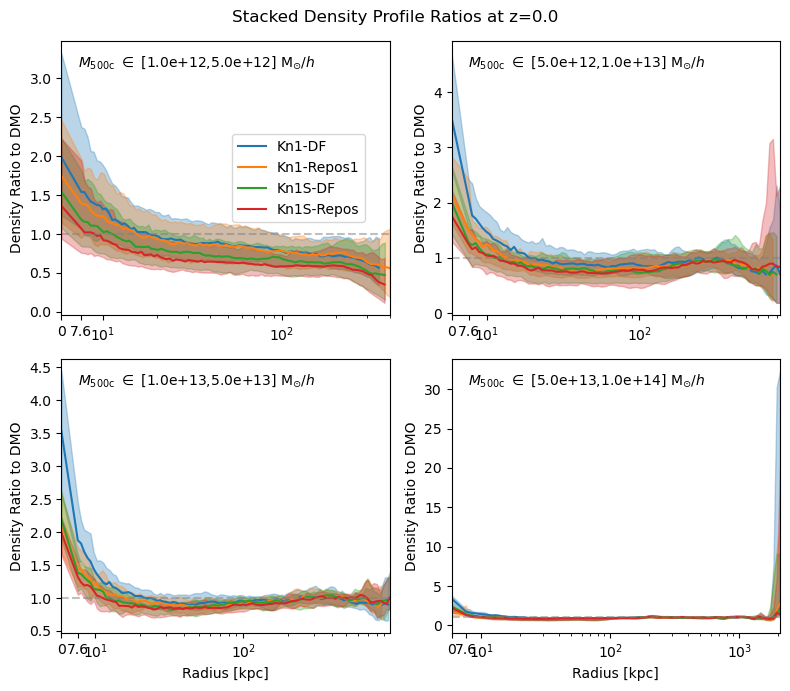

In [7]:
from matplotlib.ticker import SymmetricalLogLocator, LogLocator, NullFormatter

# figure of density profile ratio, 2x2 panels, for mass ranges 1e12-5e12, 5e12-1e13, 1e13-5e13, 5e13-1e14 Msun/h

m_ranges = [(1e12, 5e12), (5e12, 1e13), (1e13, 5e13), (5e13, 1e14)]

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

# flatten axes for easy iteration
axes = axes.flatten()

for i, (m_lower, m_upper) in enumerate(m_ranges):

    # stacked density profiles
    
    # r_kn0R1, rho_kn0R1, rho_p16_kn0R1, rho_p84_kn0R1 = get_stacked_rho_profile(pigs_kn0R1[idx_z], m_lower, m_upper)
    # r_kn1R1, rho_kn1R1, rho_p16_kn1R1, rho_p84_kn1R1 = get_stacked_rho_profile(pigs_kn1R1[idx_z], m_lower, m_upper)
    # r_kn1DF, rho_kn1DF, rho_p16_kn1DF, rho_p84_kn1DF = get_stacked_rho_profile(pigs_kn1DF[idx_z], m_lower, m_upper)
    # r_dmo, rho_dmo, rho_p16_dmo, rho_p84_dmo = get_stacked_rho_profile(pigs_dmo[idx_z], m_lower, m_upper)
    # r_kn1SR1, rho_kn1SR1, rho_p16_kn1SR1, rho_p84_kn1SR1 = get_stacked_rho_profile(pigs_kn1SR1[idx_z], m_lower, m_upper)
    # r_kn1SDF, rho_kn1SDF, rho_p16_kn1SDF, rho_p84_kn1SDF = get_stacked_rho_profile(pigs_kn1SDF[idx_z], m_lower, m_upper)

    # ratio of hydro to DMO
    r_common_kn1DF, ratio_kn1DF, ratio_kn1DF_p16, ratio_kn1DF_p84 = get_matched_profile_ratio(pigs_dmo[idx_z], pigs_kn1DF[idx_z], gids_dmo_common, gids_hydro_df_common, m_lower, m_upper)
    plot_stacked(axes[i], r_common_kn1DF, ratio_kn1DF, ratio_kn1DF_p16, ratio_kn1DF_p84, label_sim='Kn1-DF', color='C0')

    r_common_kn1R1, ratio_kn1R1, ratio_kn1R1_p16, ratio_kn1R1_p84 = get_matched_profile_ratio(pigs_dmo[idx_z], pigs_kn1R1[idx_z], gids_dmo_common, gids_hydro_r1_common, m_lower, m_upper)
    plot_stacked(axes[i], r_common_kn1R1, ratio_kn1R1, ratio_kn1R1_p16, ratio_kn1R1_p84, label_sim='Kn1-Repos1', color='C1')

    r_common_kn1SDF, ratio_kn1SDF, ratio_kn1SDF_p16, ratio_kn1SDF_p84 = get_matched_profile_ratio(pigs_dmo[idx_z], pigs_kn1SDF[idx_z], gids_dmo_common, gids_hydro_sdf_common, m_lower, m_upper)
    plot_stacked(axes[i], r_common_kn1SDF, ratio_kn1SDF, ratio_kn1SDF_p16, ratio_kn1SDF_p84, label_sim='Kn1S-DF', color='C2')

    r_common_kn1SR1, ratio_kn1SR1, ratio_kn1SR1_p16, ratio_kn1SR1_p84 = get_matched_profile_ratio(pigs_dmo[idx_z], pigs_kn1SR1[idx_z], gids_dmo_common, gids_hydro_sr1_common,  m_lower, m_upper)
    plot_stacked(axes[i], r_common_kn1SR1, ratio_kn1SR1, ratio_kn1SR1_p16, ratio_kn1SR1_p84, label_sim='Kn1S-Repos', color='C3')

    # horizontal line at y=1
    axes[i].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    

    axes[i].set_ylabel('Density Ratio to DMO')

    # annotate mass range using text
    axes[i].text(0.05, 0.95, r'$M_\mathrm{500c}$ $\in$ [%.1e,%.1e] M$_{\odot}/h$' % (m_lower, m_upper), transform=axes[i].transAxes, 
                 verticalalignment='top') 
    # x lower limit as the minimum non-zero r_common among all sims
    r_min_nz = min([r_common_kn1R1[r_common_kn1R1>0].min(),
                    r_common_kn1DF[r_common_kn1DF>0].min(), r_common_kn1SR1[r_common_kn1SR1>0].min(),
                    r_common_kn1SDF[r_common_kn1SDF>0].min()])
    # x upper limit maximum r
    r_max = max([r_common_kn1R1.max(), r_common_kn1DF.max(), r_common_kn1SR1.max(),
                    r_common_kn1SDF.max()])

    
    axes[i].set_xscale('symlog', linthresh=r_min_nz, linscale=0.1)
    # x ticks
    axes[i].set_xticks([0, r_min_nz, 1e1, 1e2, 1e3],[0, '%.1f' % r_min_nz, r'$10^1$', r'$10^2$', r'$10^3$'])
    # show minor ticks
    # axes[i].minorticks_on()
    # ticks = axes[i].xaxis.get_minor_locator().tick_values(r_min_nz, r_max)
    # ticks = ticks[(ticks >= 10) & (ticks <= r_max)]
    # axes[i].set_xticks(ticks, minor=True)
    # axes[i].xaxis.set_minor_locator(
    #     LogLocator(base=10.0, linthresh=r_min_nz, subs=np.arange(2, 10) * 0.1)
    # )
    # axes[i].xaxis.set_minor_locator(
    # SymmetricalLogLocator(
    #     base=10,
    #     linthresh=r_min_nz,
    #     subs=np.arange(2, 10)
    #     )
    # )
    # axes[i].xaxis.set_minor_formatter(NullFormatter())
    # 1. Define the minor tick values between 10 and 10000
    # This creates [20, 30...90] and [200, 300...900]
    minor_ticks = np.concatenate([np.arange(2, 10) * 10, 
                                 np.arange(2, 10) * 100, 
                                 np.arange(2, 10) * 1000])
    
    # 2. Apply them to the x-axis
    axes[i].set_xticks(minor_ticks, minor=True)
    
    # 3. Ensure they don't have labels (standard for minor ticks)
    axes[i].xaxis.set_minor_formatter(NullFormatter())
    axes[i].set_xlim(0, r_max)

# x label only for bottom panels
for i in [2, 3]:
    axes[i].set_xlabel('Radius [kpc]')

# legend only for the first panel
axes[0].legend(loc='center left', bbox_to_anchor=(.5, 0.5))

plt.suptitle(f'Stacked Density Profile Ratios at z={z_list[idx_z]}')
plt.tight_layout()
plt.show()

Median R500c for DMO in mass range [100000000000.0, 1000000000000.0): 69.20 kpc
Median R500c for DMO in mass range [1000000000000.0, 10000000000000.0): 156.82 kpc
Median R500c for DMO in mass range [10000000000000.0, 100000000000000.0): 318.74 kpc


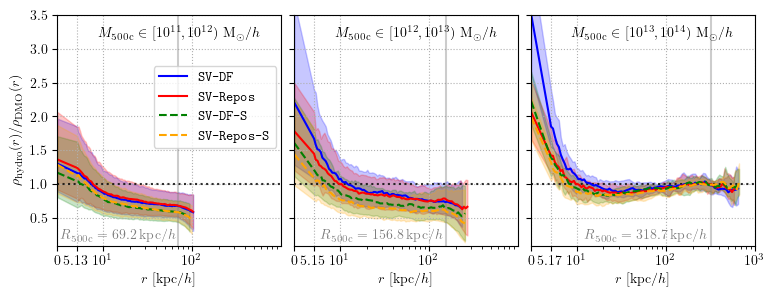

In [ ]:
# plot for z = 0: 3 columns for mass ranges 1e11-1e12, 1e12-1e13, 1e13-1e14 Msun/h

def get_median_r500c(pig_dmo, gids_dmo_common, m_lower, m_upper):
    # get the r500c for the common matched groups in DMO
    r500c_dmo = pig_dmo['FOFGroups/R500c'][:][gids_dmo_common-1]
    m500c_dmo = pig_dmo['FOFGroups/M500c'][:][gids_dmo_common-1]
    # select the groups in the mass range
    mask = (m500c_dmo >= m_lower/1e10) & (m500c_dmo < m_upper/1e10)
    r500c_selected = r500c_dmo[mask]
    r500c_median = np.median(r500c_selected)
    print(f'Median R500c for DMO in mass range [{m_lower}, {m_upper}): {r500c_median:.2f} kpc')
    # return the median r500c
    return r500c_median

# hubble parameters for unit conversion
h = 0.6774

import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
# font
plt.rcParams["font.family"] = 'Nimbus Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

m_ranges = [(1e11, 1e12), (1e12, 1e13), (1e13, 1e14)]
m_ranges_labels = [r'$10^{11}, 10^{12}$', r'$10^{12}, 10^{13}$', r'$10^{13}, 10^{14}$']

R_pos = [0.27, 0.39, 0.51]

colors = ['blue', 'red', 'green', 'orange']
alpha_fill = 0.22

# ratio limits
# ratio_lims = [()]

fig, axes = plt.subplots(1, 3, figsize=(9., 3))
fig.subplots_adjust(wspace=0.06)

for i, (m_lower, m_upper) in enumerate(m_ranges):

    # horizontal line at y=1
    axes[i].axhline(1.0, color='black', linestyle=':', alpha=.8)

    # plot the median R500c for the DMO sample in this mass range as a vertical line
    R500c_median = get_median_r500c(pigs_dmo[idx_z], gids_dmo_common, m_lower, m_upper)
    axes[i].axvline(R500c_median, color='gray', linestyle='-', alpha=0.4)
    # text, specify the position
    axes[i].text(R_pos[i], 0.07, r'$R_\mathrm{500c}$ = %.1f$\,$kpc$/h$' % R500c_median, transform=axes[i].transAxes,
                 verticalalignment='top', horizontalalignment='center', color='gray')
    
    # convert length unit from kpc to kpc/h

    # ratio of hydro to DMO
    r_common_kn1DF, ratio_kn1DF, ratio_kn1DF_p16, ratio_kn1DF_p84 = get_matched_profile_ratio(pigs_dmo[idx_z], pigs_kn1DF[idx_z], gids_dmo_common, gids_hydro_df_common, m_lower, m_upper)
    r_common_kn1DF *= h  # convert kpc to kpc/h
    plot_stacked(axes[i], r_common_kn1DF, ratio_kn1DF, ratio_kn1DF_p16, ratio_kn1DF_p84, label_sim=r'\textsc{SV-DF}', color=colors[0], alpha=alpha_fill)
    r_common_kn1R1, ratio_kn1R1, ratio_kn1R1_p16, ratio_kn1R1_p84 = get_matched_profile_ratio(pigs_dmo[idx_z], pigs_kn1R1[idx_z], gids_dmo_common, gids_hydro_r1_common, m_lower, m_upper)
    r_common_kn1R1 *= h  # convert kpc to kpc/h
    plot_stacked(axes[i], r_common_kn1R1, ratio_kn1R1, ratio_kn1R1_p16, ratio_kn1R1_p84, label_sim=r'\textsc{SV-Repos}', color=colors[1], alpha=alpha_fill)
    r_common_kn1SDF, ratio_kn1SDF, ratio_kn1SDF_p16, ratio_kn1SDF_p84 = get_matched_profile_ratio(pigs_dmo[idx_z], pigs_kn1SDF[idx_z], gids_dmo_common, gids_hydro_sdf_common, m_lower, m_upper)
    r_common_kn1SDF *= h  # convert kpc to kpc/h
    plot_stacked(axes[i], r_common_kn1SDF, ratio_kn1SDF, ratio_kn1SDF_p16, ratio_kn1SDF_p84, label_sim=r'\textsc{SV-DF-S}', color=colors[2], ls='--', alpha=alpha_fill)
    r_common_kn1SR1, ratio_kn1SR1, ratio_kn1SR1_p16, ratio_kn1SR1_p84 = get_matched_profile_ratio(pigs_dmo[idx_z], pigs_kn1SR1[idx_z], gids_dmo_common, gids_hydro_sr1_common,  m_lower, m_upper)
    r_common_kn1SR1 *= h  # convert kpc to kpc/h
    plot_stacked(axes[i], r_common_kn1SR1, ratio_kn1SR1, ratio_kn1SR1_p16, ratio_kn1SR1_p84, label_sim=r'\textsc{SV-Repos-S}', color=colors[3], ls='--', alpha=alpha_fill)

    # annotate mass range using text
    axes[i].text(0.18, 0.95, r'$M_\mathrm{500c}$ $\in$ [%s) M$_{\odot}/h$' % m_ranges_labels[i], transform=axes[i].transAxes, 
                 verticalalignment='top')
    # x lower limit as the minimum non-zero r_common among all sims
    r_min_nz = min([r_common_kn1R1[r_common_kn1R1>0].min(),
                    r_common_kn1DF[r_common_kn1DF>0].min(), r_common_kn1SR1[r_common_kn1SR1>0].min(),
                    r_common_kn1SDF[r_common_kn1SDF>0].min()])
    # x upper limit maximum r
    r_max = max([r_common_kn1R1.max(), r_common_kn1DF.max(), r_common_kn1SR1.max(),
                    r_common_kn1SDF.max()]) 
    
    axes[i].set_xscale('symlog', linthresh=r_min_nz, linscale=0.2)
    # x ticks
    if i < 2:
        axes[i].set_xticks([0, r_min_nz, 1e1, 1e2],[0, '', r'$10^1$', r'$10^2$'])
    else:
        axes[i].set_xticks([0, r_min_nz, 1e1, 1e2, 1e3],[0, '', r'$10^1$', r'$10^2$', r'$10^3$'])
    # manually set the label for r_min_z
    axes[i].text(0.08, -0.04, '%.2f' % r_min_nz, transform=axes[i].transAxes,
                 verticalalignment='top', horizontalalignment='center', fontsize=10)
    
    # show minor ticks
    minor_ticks = np.concatenate([np.arange(2, 10) * 10, 
                                 np.arange(2, 10) * 100, 
                                 np.arange(2, 10) * 1000])
    axes[i].set_xticks(minor_ticks, minor=True)
    axes[i].xaxis.set_minor_formatter(NullFormatter())

    axes[i].set_xlim(0, 1e3)
    axes[i].set_ylim(0.1, 3.5)
    axes[i].set_xlabel(r'$r\ [\mathrm{kpc}/h]$')
    if i == 0:
        axes[i].set_ylabel(r'$\rho_\mathrm{hydro}(r)/\rho_\mathrm{DMO}(r)$')
    else:
        axes[i].set_ylabel("")
        axes[i].set_yticklabels([])
    # grid
    axes[i].grid(linestyle=':')

# legend only for the first panel
axes[0].legend(loc='center left', bbox_to_anchor=(.4, 0.6))
# plt.tight_layout()
plt.savefig('fig_profile_ratio_matched_z0.pdf',bbox_inches='tight')
